### Clone Project Repository

In [71]:
import sys
import os

KAGGLE = True # Change to false if running locally

if KAGGLE:
    # clone repo to get project modules
    if not os.path.exists("Dissertation"):
        os.system("git clone https://github.com/Hamzaabba2005/Dissertation.git")
    else:
        print("Already exists")
    sys.path.append("/kaggle/working/Dissertation/project/src")
else:
    # locally, just point to the src folder
    sys.path.append("../project/src")

Already exists


### Importing Project Modules

In [72]:
# standard library
import os
import random
import copy

# third party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pickle
import shutil

# torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# sklearn
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    average_precision_score,
)

# project modules
from config import DEVICE, LR, EPOCHS, WEIGHT_DECAY, LABEL_COLS, IMG_SIZE, TRAIN_BS, VAL_BS, VAL_SIZE
from reproducibility import seed_everything
from auto_detect import pick_images_dir
from build_samples import build_samples_existing
from patient_level_split import patient_level_split
from transforms_config import get_transforms
from dataset import create_dataloaders
from class_weights import compute_pos_weight
from model import build_model
from thresholds import (
    tune_thresholds_per_class,
    predict_with_thresholds,
    evaluate_with_thresholds,
    threshold_report,
)

### Configuration

In [73]:
if KAGGLE:
    CHECKPOINT_DIR = "/kaggle/working/checkpoints"
    OUTPUT_DIR = "/kaggle/working"
else:
    CHECKPOINT_DIR = "checkpoints"
    OUTPUT_DIR = "."

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

### Dataset Paths and Environment Check

In [74]:
if KAGGLE:
    BASE_PATH = os.getenv("DATASET_PATH", "/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k")
else:
    BASE_PATH = "data"

CSV_PATH = os.path.join(BASE_PATH, "full_df.csv")
IMAGES_DIR = os.path.join(BASE_PATH, "preprocessed_images")

print("CSV exists:", os.path.exists(CSV_PATH))
print("Images dir exists:", os.path.exists(IMAGES_DIR))
print("Device:", DEVICE)
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
print("Current device:", torch.cuda.current_device() if torch.cuda.is_available() else "CPU")
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CSV exists: True
Images dir exists: True
Device: cuda
CUDA available: True
Device count: 1
Current device: 0
GPU name: Tesla P100-PCIE-16GB


### Set Random Seed

In [75]:
SEED = 42
seed_everything(SEED)

### Load Dataset Metadata

In [76]:
df = pd.read_csv(CSV_PATH)
print("CSV shape:", df.shape)
df.head()

CSV shape: (6392, 19)


,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg


### Auto-Detect Image Directory

In [77]:
auto_dir, hits = pick_images_dir(BASE_PATH, df)

if auto_dir is not None and hits > 0:
    IMAGES_DIR = auto_dir

print("Selected IMAGES_DIR:", IMAGES_DIR)
print("Hits:", hits)

Selected IMAGES_DIR: /kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k/preprocessed_images
Hits: 39


### Build Dataset Samples

In [78]:
samples, missing, bad_labels = build_samples_existing(df, IMAGES_DIR, LABEL_COLS)

print("Total usable samples:", len(samples))
print("Missing images:", missing)
print("Bad label rows:", bad_labels)

Total usable samples: 12460
Missing images: 324
Bad label rows: 0


### Patient-Level Train / Validation / Test Split 

In [79]:
trainval_samples, test_samples = patient_level_split(samples, val_size=0.15, seed=SEED)

VAL_FRAC_OF_REMAINING = VAL_SIZE / (1.0 - 0.15)
train_samples, val_samples = patient_level_split(trainval_samples, val_size=VAL_FRAC_OF_REMAINING, seed=SEED)

train_patients = set(s["patient_id"] for s in train_samples)
val_patients = set(s["patient_id"] for s in val_samples)
test_patients = set(s["patient_id"] for s in test_samples)

print("Train samples:", len(train_samples),"| patients:", len(train_patients))
print("Val samples:", len(val_samples),"| patients:", len(val_patients))
print("Test samples:", len(test_samples),"| patients:", len(test_patients))
print("Train/Val overlap:", len(train_patients & val_patients))
print("Train/Test overlap:", len(train_patients & test_patients))
print("Val/Test overlap:", len(val_patients & test_patients))

Train samples: 8722 | patients: 2350
Val samples: 1887 | patients: 504
Test samples: 1851 | patients: 504
Train/Val overlap: 0
Train/Test overlap: 0
Val/Test overlap: 0


### Image Transformations

In [80]:
train_tfm, val_tfm = get_transforms(IMG_SIZE)

### Show Augmentation Effect

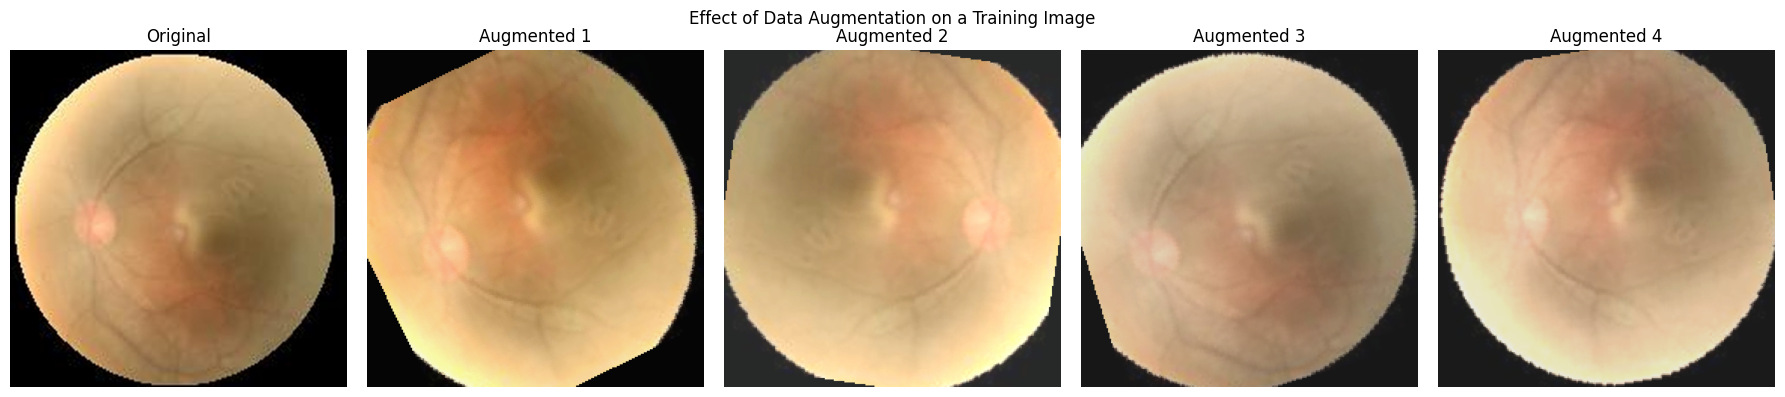

In [81]:
sample = train_samples[100]
original = Image.open(sample["path"]).convert("RGB")

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

axes[0].imshow(original)
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(1, 5):
    augmented = train_tfm(original).permute(1, 2, 0).numpy()
    augmented = np.clip(augmented * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)
    axes[i].imshow(augmented)
    axes[i].set_title(f"Augmented {i}")
    axes[i].axis("off")

plt.suptitle("Effect of Data Augmentation on a Training Image", fontsize=12)
plt.tight_layout()
plt.show()

### Create DataLoaders

In [82]:
train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = create_dataloaders(
    train_samples, val_samples, train_tfm, val_tfm, test_samples=test_samples
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 137
Val batches: 15
Test batches: 15


### Compute Class Weights

In [83]:
pos_weight = compute_pos_weight(train_samples).to(DEVICE)
print("pos_weight:", pos_weight)

pos_weight: tensor([ 1.9417,  1.9526, 14.9452, 14.6029, 19.6682, 28.4662, 19.8162,  3.4959],
       device='cuda:0')


### Visualise Example Training Images

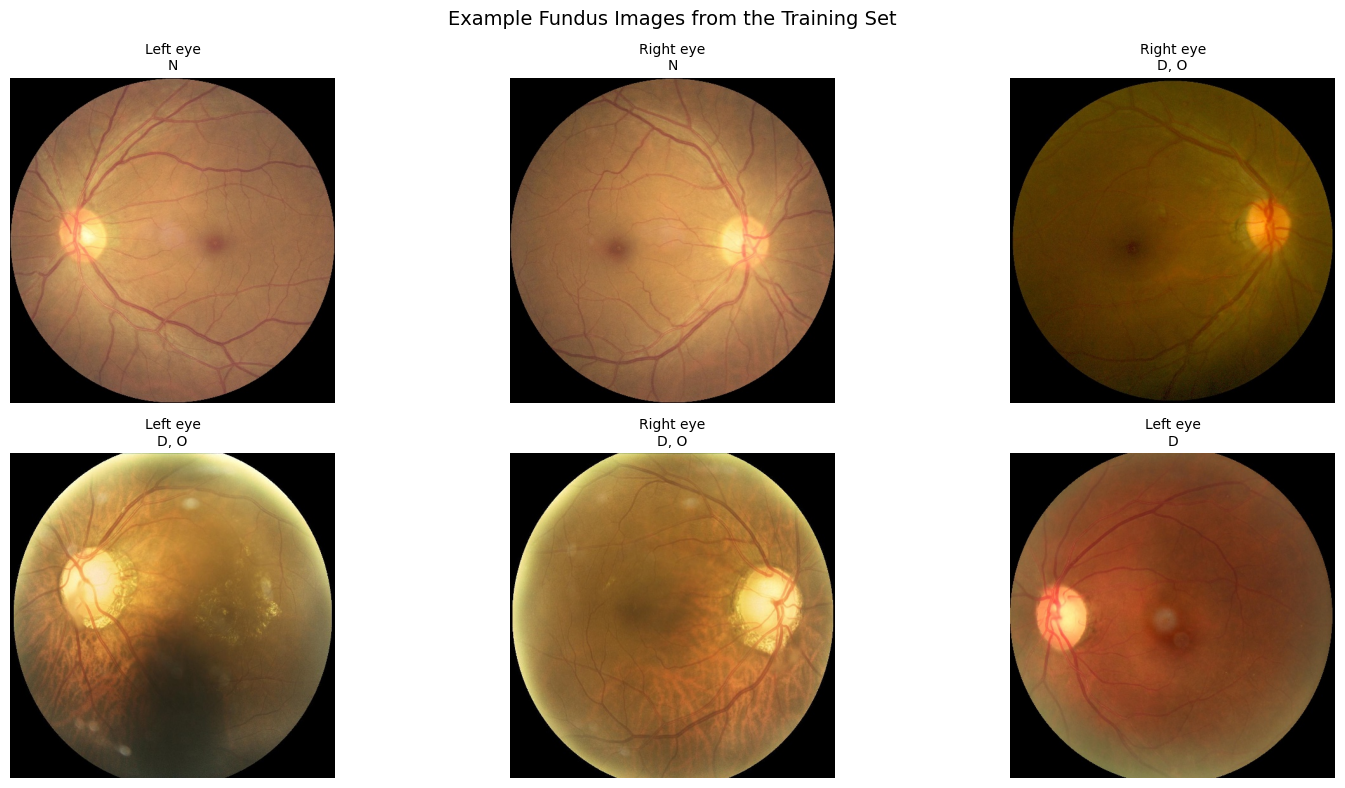

In [84]:
def show_sample_images(samples, n=6):
    n = min(n, len(samples))
    fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(16, 8))
    axes = np.array(axes).reshape(-1)

    for ax, sample in zip(axes, samples[:n]):
        img = Image.open(sample["path"]).convert("RGB")
        ax.imshow(img)
        positive_labels = [LABEL_COLS[i] for i, v in enumerate(sample["label"]) if v > 0]
        ax.set_title(f"{sample['side']} eye\n" + ", ".join(positive_labels), fontsize=10)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.suptitle("Example Fundus Images from the Training Set", fontsize=14)
    plt.tight_layout()
    plt.show()

show_sample_images(train_samples, n=6)

### Label Distribution


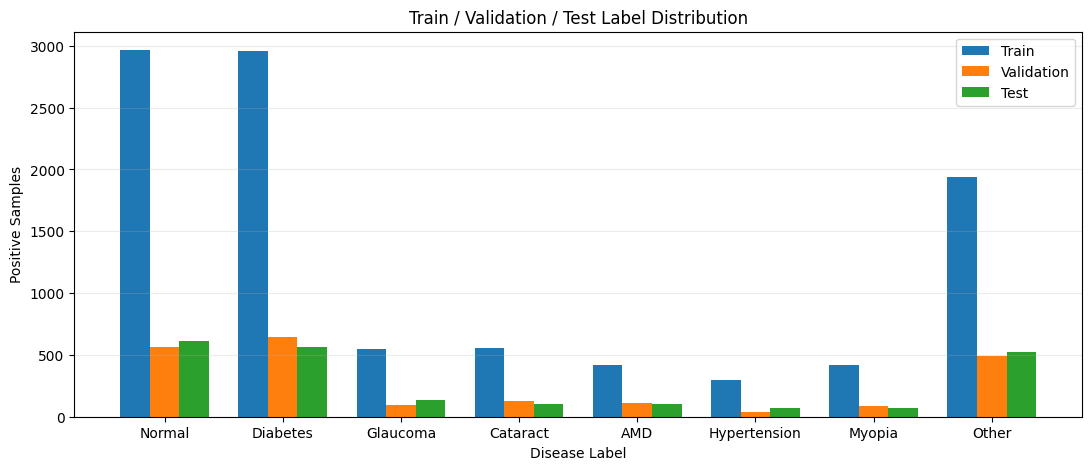

In [85]:
CLASS_NAMES = ["Normal", "Diabetes", "Glaucoma", "Cataract", "AMD", "Hypertension", "Myopia", "Other"] # 

train_label_counts = np.stack([s["label"] for s in train_samples]).sum(axis=0)
val_label_counts = np.stack([s["label"] for s in val_samples]).sum(axis=0)
test_label_counts = np.stack([s["label"] for s in test_samples]).sum(axis=0)

x = np.arange(len(CLASS_NAMES))
width = 0.25

plt.figure(figsize=(13, 5))
plt.bar(x - width, train_label_counts, width=width, label="Train")
plt.bar(x, val_label_counts, width=width, label="Validation")
plt.bar(x + width, test_label_counts, width=width, label="Test")
plt.xticks(x, CLASS_NAMES)
plt.title("Train / Validation / Test Label Distribution")
plt.xlabel("Disease Label")
plt.ylabel("Positive Samples")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()

In [86]:
total = len(train_samples)
print("Class imbalance in training set:")
for i, col in enumerate(CLASS_NAMES):
    count = int(train_label_counts[i])
    pct = count / total * 100
    print(f"{col}: {count} ({pct:.1f}%)")

Class imbalance in training set:
Normal: 2965 (34.0%)
Diabetes: 2954 (33.9%)
Glaucoma: 547 (6.3%)
Cataract: 559 (6.4%)
AMD: 422 (4.8%)
Hypertension: 296 (3.4%)
Myopia: 419 (4.8%)
Other: 1940 (22.2%)


### Model Initialisation


In [87]:
MODEL_NAME = "efficientnet_b0"
# options: "resnet18", "resnet50", "efficientnet_b0", "custom_cnn"

model = build_model(
    model_name=MODEL_NAME,
    num_labels=len(LABEL_COLS),
    dropout=0.45,
    pretrained=(MODEL_NAME != "custom_cnn")
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

print("Using model:", MODEL_NAME)
print(model.__class__.__name__)

Using model: efficientnet_b0
EfficientNet


### Training and Validation Loop


In [88]:
def multilabel_accuracy(probs, y, threshold=0.3):
    preds = (probs >= threshold).to(y.dtype)
    return (preds == y).float().mean().item()

def train_one_epoch(model, loader, criterion, optimizer, device="cpu"):
    model.train()
    total_loss, total_acc, n = 0.0, 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device).float()
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        probs = torch.sigmoid(logits)
        total_loss += loss.item() * x.size(0)
        total_acc += multilabel_accuracy(probs, y) * x.size(0)
        n += x.size(0)

    return {"loss": total_loss / n, "acc": total_acc / n}


@torch.no_grad()
def evaluate_epoch(model, loader, criterion, device="cpu", threshold=0.5):
    model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0
    all_probs, all_targets = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device).float()
        logits = model(x)
        loss = criterion(logits, y)
        probs = torch.sigmoid(logits)

        total_loss += loss.item() * x.size(0)
        total_acc += multilabel_accuracy(probs, y, threshold) * x.size(0)
        n += x.size(0)
        all_probs.append(probs.cpu())
        all_targets.append(y.cpu())

    probs = torch.cat(all_probs).numpy()
    targets = torch.cat(all_targets).numpy().astype(int)
    preds = (probs >= threshold).astype(int)

    return {
        "loss": total_loss / n,
        "acc": total_acc / n,
        "macro_f1": f1_score(targets, preds, average="macro", zero_division=0),
        "micro_f1": f1_score(targets, preds, average="micro", zero_division=0),
        "exact_match": (preds == targets).all(axis=1).mean(),
        "per_class_f1": f1_score(targets, preds, average=None, zero_division=0),
        "probs": probs,
        "preds": preds,
        "targets": targets,
    }


# training setup
best_val_loss = float("inf")
best_val_macro_f1 = -1.0
best_epoch_f1 = best_epoch_loss = -1
best_state_f1 = best_state_loss = None
best_metrics_f1 = None
history = []
patience = 5
no_improve = 0

for epoch in range(1, EPOCHS + 1):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_metrics = evaluate_epoch(model, val_loader, criterion, DEVICE)

    best_thresholds, _ = tune_thresholds_per_class(val_metrics["probs"], val_metrics["targets"])
    tuned_metrics = evaluate_with_thresholds(val_metrics["probs"], val_metrics["targets"], best_thresholds)

    scheduler.step(val_metrics["macro_f1"])
    lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["acc"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["acc"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_micro_f1": val_metrics["micro_f1"],
        "val_exact_match": val_metrics["exact_match"],
        "lr": lr,
    })

    print(f"Epoch {epoch:02d} | train loss {train_metrics['loss']:.4f} acc {train_metrics['acc']:.4f} | val loss {val_metrics['loss']:.4f} acc {val_metrics['acc']:.4f} | f1@0.5 {val_metrics['macro_f1']:.4f} | f1_tuned {tuned_metrics['macro_f1']:.4f} | lr {lr:.6f}")

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_epoch_loss = epoch
        best_state_loss = copy.deepcopy(model.state_dict())

    if val_metrics["macro_f1"] > best_val_macro_f1:
        best_val_macro_f1 = val_metrics["macro_f1"]
        best_epoch_f1 = epoch
        best_state_f1 = copy.deepcopy(model.state_dict())
        best_metrics_f1 = {
            "loss": val_metrics["loss"],
            "acc@0.5": val_metrics["acc"],
            "macro_f1@0.5": val_metrics["macro_f1"],
            "micro_f1@0.5": val_metrics["micro_f1"],
            "exact@0.5": val_metrics["exact_match"],
            "per_class_f1@0.5": val_metrics["per_class_f1"],
            "macro_f1_tuned": tuned_metrics["macro_f1"],
            "micro_f1_tuned": tuned_metrics["micro_f1"],
            "exact_tuned": tuned_metrics["exact_match"],
            "per_class_f1_tuned": tuned_metrics["per_class_f1"],
        }
        no_improve = 0
    else:
        no_improve += 1
        print(f"No improvement for {no_improve} epoch(s)")

    if no_improve >= patience:
        print(f"Early stopping at epoch {epoch}. Best F1: {best_val_macro_f1:.4f} at epoch {best_epoch_f1}")
        break

Epoch 01 | train loss 0.9262 acc 0.4039 | val loss 0.8264 acc 0.7714 | f1@0.5 0.4064 | f1_tuned 0.4980 | lr 0.000300
Epoch 02 | train loss 0.7779 acc 0.5864 | val loss 0.8044 acc 0.7762 | f1@0.5 0.4282 | f1_tuned 0.5196 | lr 0.000300
Epoch 03 | train loss 0.7023 acc 0.6391 | val loss 0.8779 acc 0.8082 | f1@0.5 0.4612 | f1_tuned 0.5433 | lr 0.000300
Epoch 04 | train loss 0.6585 acc 0.6697 | val loss 0.8021 acc 0.7855 | f1@0.5 0.4436 | f1_tuned 0.5410 | lr 0.000300
No improvement for 1 epoch(s)
Epoch 05 | train loss 0.5960 acc 0.7026 | val loss 0.9643 acc 0.8233 | f1@0.5 0.4503 | f1_tuned 0.5199 | lr 0.000300
No improvement for 2 epoch(s)
Epoch 06 | train loss 0.5622 acc 0.7298 | val loss 0.8753 acc 0.8271 | f1@0.5 0.4708 | f1_tuned 0.5547 | lr 0.000300
Epoch 07 | train loss 0.5210 acc 0.7492 | val loss 0.9400 acc 0.8225 | f1@0.5 0.4573 | f1_tuned 0.5403 | lr 0.000300
No improvement for 1 epoch(s)
Epoch 08 | train loss 0.5016 acc 0.7635 | val loss 0.9713 acc 0.8204 | f1@0.5 0.4461 | f1_t

### Tune Decision Thresholds

In [89]:
probs = val_metrics["probs"]
targets = val_metrics["targets"]

best_thresholds, _ = tune_thresholds_per_class(probs, targets)

### Save Model Checkpoints


In [90]:
best_model_f1_path = os.path.join(CHECKPOINT_DIR, f"{MODEL_NAME}_odir_multilabel_best_f1.pt")
best_model_loss_path = os.path.join(CHECKPOINT_DIR, f"{MODEL_NAME}_odir_multilabel_best_loss.pt")
last_model_path = os.path.join(CHECKPOINT_DIR, f"{MODEL_NAME}_odir_multilabel_last.pt")
history_path = os.path.join(CHECKPOINT_DIR, f"{MODEL_NAME}_training_history.csv")

if best_state_f1 is not None:
    torch.save(best_state_f1, best_model_f1_path)
if best_state_loss is not None:
    torch.save(best_state_loss, best_model_loss_path)
torch.save(model.state_dict(), last_model_path)
pd.DataFrame(history).to_csv(history_path, index=False)

print(f"Best epoch by val macro F1: {best_epoch_f1}")
print(f"Best epoch by val loss: {best_epoch_loss}")
print(f"Best val loss: {best_val_loss:.4f}")
print("Saved best F1 model:", best_model_f1_path)
print("Saved best loss model:", best_model_loss_path)
print("Saved last model:", last_model_path)
print("Saved history:", history_path)

Best epoch by val macro F1: 13
Best epoch by val loss: 4
Best val loss: 0.8021
Saved best F1 model: /kaggle/working/checkpoints/efficientnet_b0_odir_multilabel_best_f1.pt
Saved best loss model: /kaggle/working/checkpoints/efficientnet_b0_odir_multilabel_best_loss.pt
Saved last model: /kaggle/working/checkpoints/efficientnet_b0_odir_multilabel_last.pt
Saved history: /kaggle/working/checkpoints/efficientnet_b0_training_history.csv


### Core Test Metrics

In [91]:
model.load_state_dict(best_state_f1)

test_metrics = evaluate_epoch(model, test_loader, criterion, device=DEVICE, threshold=0.5)
test_probs   = test_metrics["probs"]
test_targets = test_metrics["targets"]

print(f"Test loss: {test_metrics['loss']:.4f}")
print(f"Val loss: {best_metrics_f1['loss']:.4f}")
print(f"Loss gap: {best_metrics_f1['loss'] - test_metrics['loss']:+.4f}" "\n")
print(f"Test accuracy@0.5: {test_metrics['acc']:.4f}")
print(f"Test macro F1@0.5: {test_metrics['macro_f1']:.4f}")
print(f"Test micro F1@0.5: {test_metrics['micro_f1']:.4f}")
print(f"Test exact match: {test_metrics['exact_match']:.4f}")

Test loss: 1.5034
Val loss: 1.2916
Loss gap: -0.2118

Test accuracy@0.5: 0.8397
Test macro F1@0.5: 0.5291
Test micro F1@0.5: 0.5393
Test exact match: 0.2923


### Tuned Threshold Metrics (Primary Scores)

In [92]:
test_tuned = evaluate_with_thresholds(test_probs, test_targets, best_thresholds)

print(f"Test macro F1 tuned: {test_tuned['macro_f1']:.4f}")
print(f"Test micro F1 tuned: {test_tuned['micro_f1']:.4f}")
print(f"Test exact match tuned: {test_tuned['exact_match']:.4f}\n")
print(f"Val macro F1 tuned: {best_metrics_f1['macro_f1_tuned']:.4f}")
print(f"F1 gap: {best_metrics_f1['macro_f1_tuned'] - test_tuned['macro_f1']:+.4f}")

Test macro F1 tuned: 0.5264
Test micro F1 tuned: 0.5287
Test exact match tuned: 0.2453

Val macro F1 tuned: 0.5504
F1 gap: +0.0240


### Classification Report

In [93]:
print("Tuned thresholds:")
print(classification_report(test_targets, (test_probs >= best_thresholds).astype(int), target_names=CLASS_NAMES, zero_division=0))

print("Default 0.5 threshold:")
print(classification_report(test_targets, (test_probs >= 0.5).astype(int), target_names=CLASS_NAMES, zero_division=0))

Tuned thresholds:
              precision    recall  f1-score   support

      Normal       0.45      0.89      0.60       613
    Diabetes       0.51      0.63      0.56       561
    Glaucoma       0.50      0.57      0.53       134
    Cataract       0.82      0.64      0.72       106
         AMD       0.42      0.54      0.47       101
Hypertension       0.10      0.44      0.16        71
      Myopia       0.89      0.57      0.69        72
       Other       0.41      0.55      0.47       523

   micro avg       0.44      0.67      0.53      2181
   macro avg       0.51      0.60      0.53      2181
weighted avg       0.48      0.67      0.54      2181
 samples avg       0.49      0.70      0.55      2181

Default 0.5 threshold:
              precision    recall  f1-score   support

      Normal       0.46      0.87      0.60       613
    Diabetes       0.58      0.56      0.57       561
    Glaucoma       0.50      0.57      0.53       134
    Cataract       0.52      0.75    

### Per-class F1 bar chart

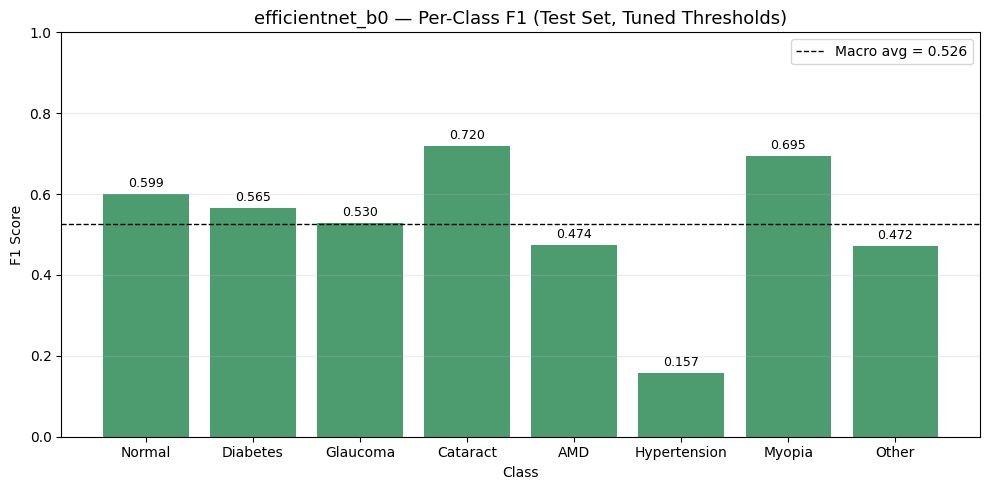

In [94]:
f1_scores = test_tuned["per_class_f1"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(CLASS_NAMES, f1_scores, color="seagreen", alpha=0.85)
ax.set_ylim(0, 1)
ax.axhline(np.mean(f1_scores), color="k", linestyle="--", lw=1, label=f"Macro avg = {np.mean(f1_scores):.3f}")
ax.set_title(f"{MODEL_NAME} — Per-Class F1 (Test Set, Tuned Thresholds)", fontsize=13)
ax.set_xlabel("Class")
ax.set_ylabel("F1 Score")
ax.legend()
ax.grid(axis="y", alpha=0.25)
for bar, val in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### Per-class F1 / Precision / Recall Heatmap

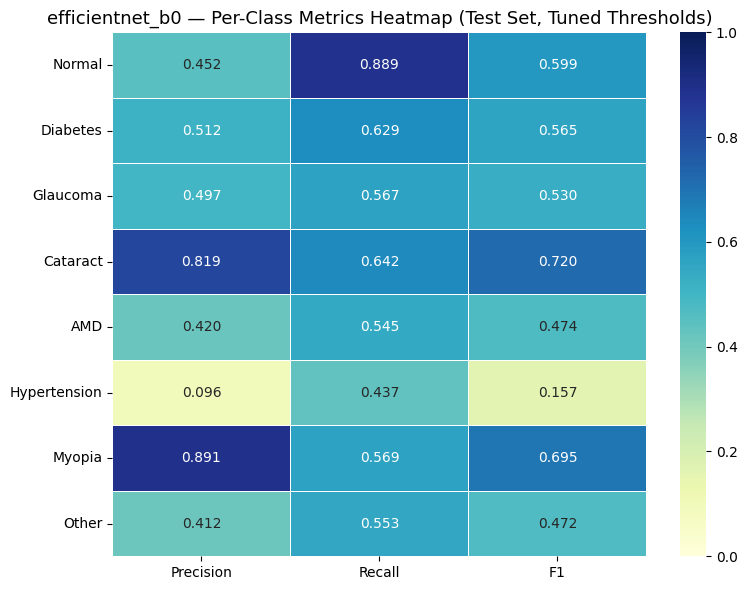

In [95]:
tuned_preds = (test_probs >= best_thresholds).astype(int)

precision  = precision_score(test_targets, tuned_preds, average=None, zero_division=0)
recall = recall_score(test_targets, tuned_preds, average=None, zero_division=0)
f1_scores = test_tuned["per_class_f1"]

metrics_df = pd.DataFrame({
    "Precision": precision,
    "Recall": recall,
    "F1": f1_scores,
}, index=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    metrics_df,
    annot=True, fmt=".3f",
    cmap="YlGnBu",
    vmin=0, vmax=1,
    ax=ax, linewidths=0.5
)
ax.set_title(f"{MODEL_NAME} — Per-Class Metrics Heatmap (Test Set, Tuned Thresholds)", fontsize=13)
plt.tight_layout()
plt.show()

### ROC-AUC & Average Precision

In [96]:
test_roc_aucs, test_avg_precs = [], []
for i, name in enumerate(CLASS_NAMES):
    if len(np.unique(test_targets[:, i])) < 2:
        test_roc_aucs.append(float("nan"))
        test_avg_precs.append(float("nan"))
    else:
        test_roc_aucs.append(roc_auc_score(test_targets[:, i], test_probs[:, i]))
        test_avg_precs.append(average_precision_score(test_targets[:, i], test_probs[:, i]))

test_macro_auc = np.nanmean(test_roc_aucs)
test_macro_ap = np.nanmean(test_avg_precs)

print(pd.DataFrame({"ROC-AUC": test_roc_aucs, "Avg Prec": test_avg_precs}, index=CLASS_NAMES).round(4))
print(f"\nMacro ROC-AUC : {test_macro_auc:.4f}")
print(f"Macro Avg Prec: {test_macro_ap:.4f}")

              ROC-AUC  Avg Prec
Normal         0.7385    0.5274
Diabetes       0.7496    0.6448
Glaucoma       0.8635    0.4696
Cataract       0.9186    0.7431
AMD            0.8449    0.5164
Hypertension   0.7570    0.1865
Myopia         0.9314    0.7571
Other          0.6631    0.4843

Macro ROC-AUC : 0.8083
Macro Avg Prec: 0.5411


### ROC Curve per class

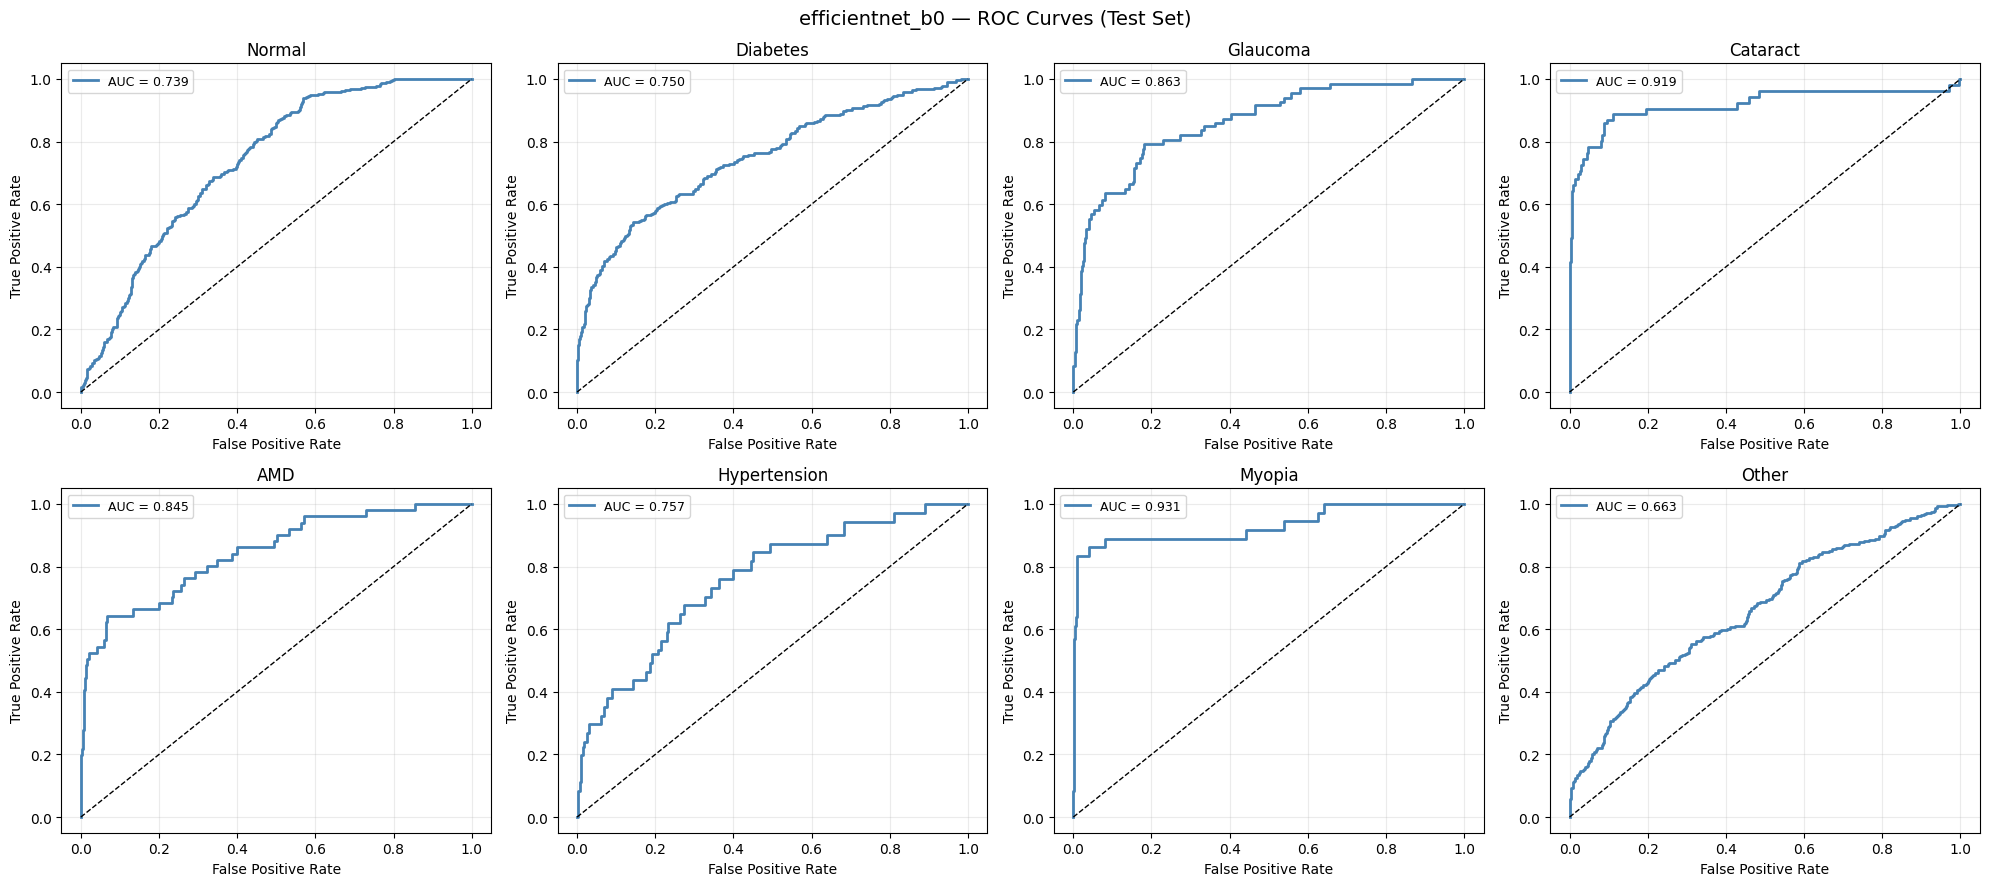

In [97]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, name in enumerate(CLASS_NAMES):
    ax = axes[i]
    if len(np.unique(test_targets[:, i])) < 2:
        ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center")
        continue
    fpr, tpr, _ = roc_curve(test_targets[:, i], test_probs[:, i])
    auc = test_roc_aucs[i]
    ax.plot(fpr, tpr, lw=2, color="steelblue", label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)

plt.suptitle(f"{MODEL_NAME} — ROC Curves (Test Set)", fontsize=14)
plt.tight_layout()
plt.show()

### Per-class AUC bar chart

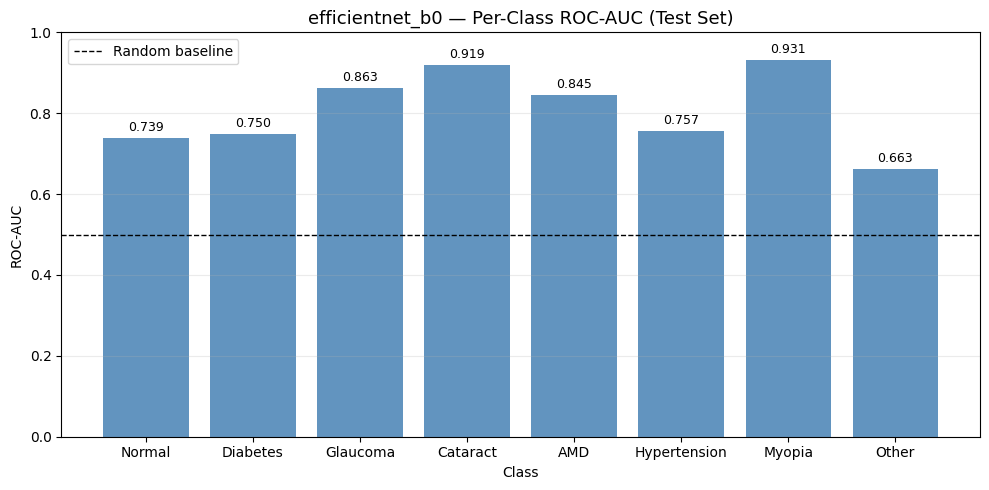

In [98]:
fig,ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(CLASS_NAMES, test_roc_aucs, color="steelblue", alpha=0.85)
ax.set_ylim(0, 1)
ax.axhline(0.5, color="k", linestyle="--", lw=1, label="Random baseline")
ax.set_title(f"{MODEL_NAME} — Per-Class ROC-AUC (Test Set)", fontsize=13)
ax.set_xlabel("Class")
ax.set_ylabel("ROC-AUC")
ax.legend()
ax.grid(axis="y", alpha=0.25)
for bar, val in zip(bars, test_roc_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### Confusion matrices

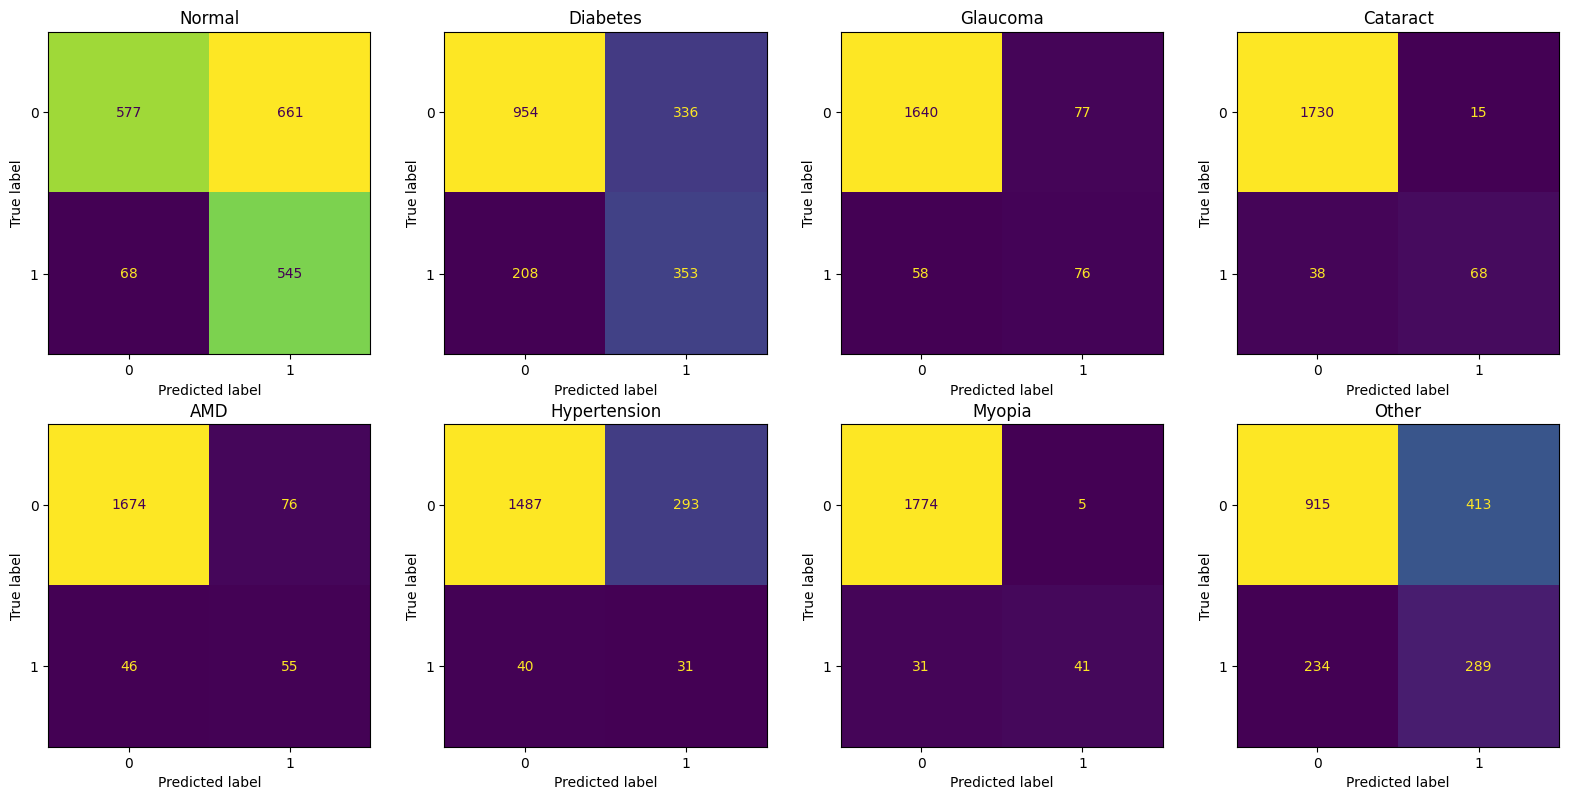

In [99]:
def plot_multilabel_confusion_matrices(targets, preds, class_names):
    cols = 4
    rows = int(np.ceil(len(class_names) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten()
    for i, name in enumerate(class_names):
        cm = confusion_matrix(targets[:, i], preds[:, i])
        ConfusionMatrixDisplay(cm).plot(ax=axes[i], colorbar=False)
        axes[i].set_title(name)
    for j in range(len(class_names), len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

plot_multilabel_confusion_matrices(
    test_targets,
    (test_probs >= best_thresholds).astype(int),
    CLASS_NAMES
)

### Grad-CAM Analysis

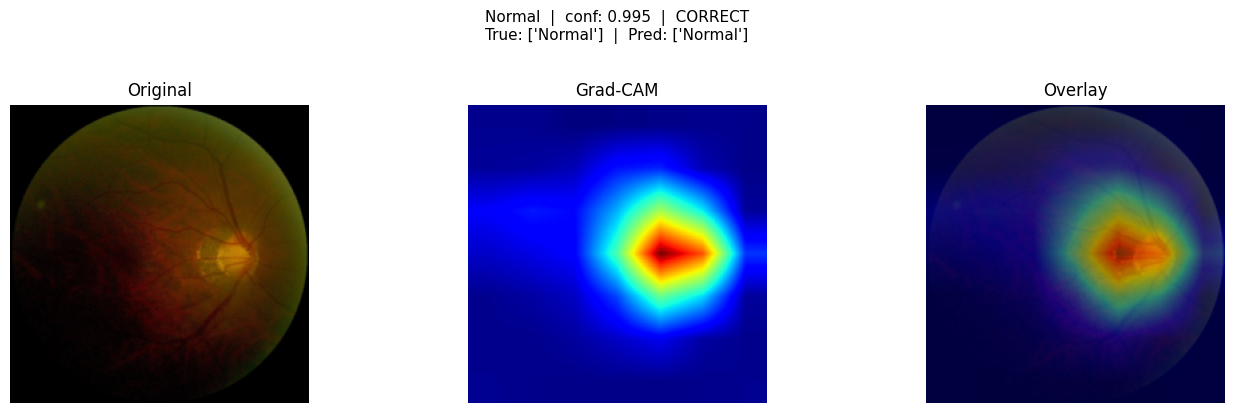


Probabilities:
Normal: 0.9950
Diabetes: 0.0086
Glaucoma: 0.0287
Cataract: 0.0009
AMD: 0.0007
Hypertension: 0.0002
Myopia: 0.0023
Other: 0.0148


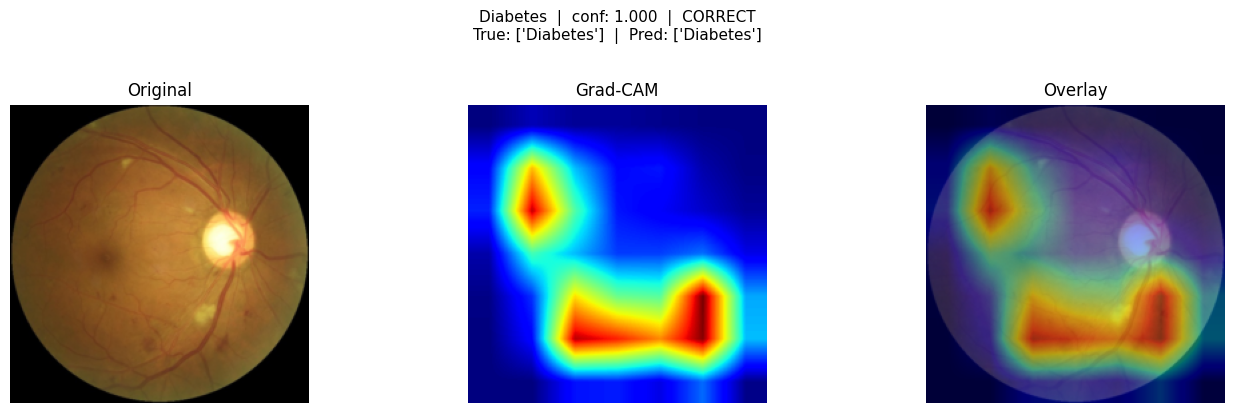


Probabilities:
Normal: 0.0000
Diabetes: 1.0000
Glaucoma: 0.0243
Cataract: 0.0469
AMD: 0.0000
Hypertension: 0.2363
Myopia: 0.0000
Other: 0.0088


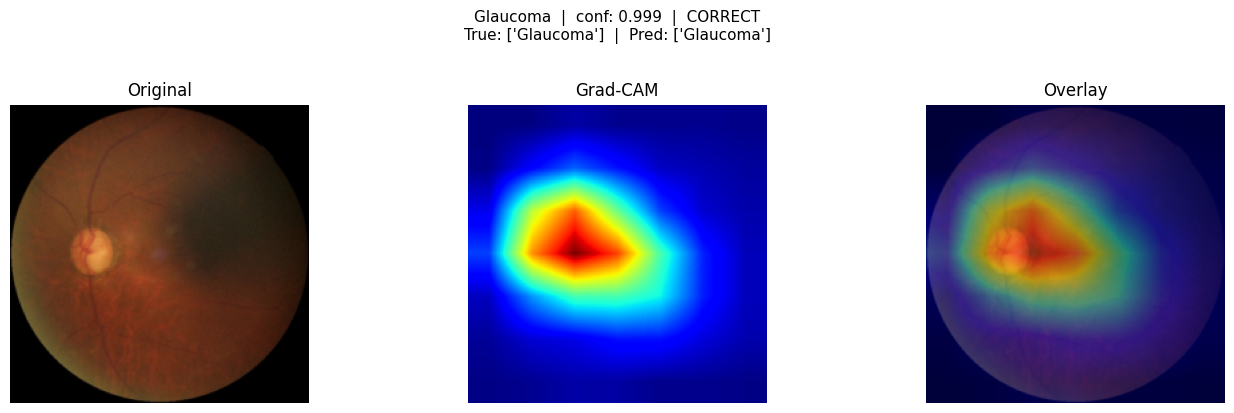


Probabilities:
Normal: 0.2468
Diabetes: 0.0151
Glaucoma: 0.9993
Cataract: 0.0026
AMD: 0.0007
Hypertension: 0.0002
Myopia: 0.0107
Other: 0.0395


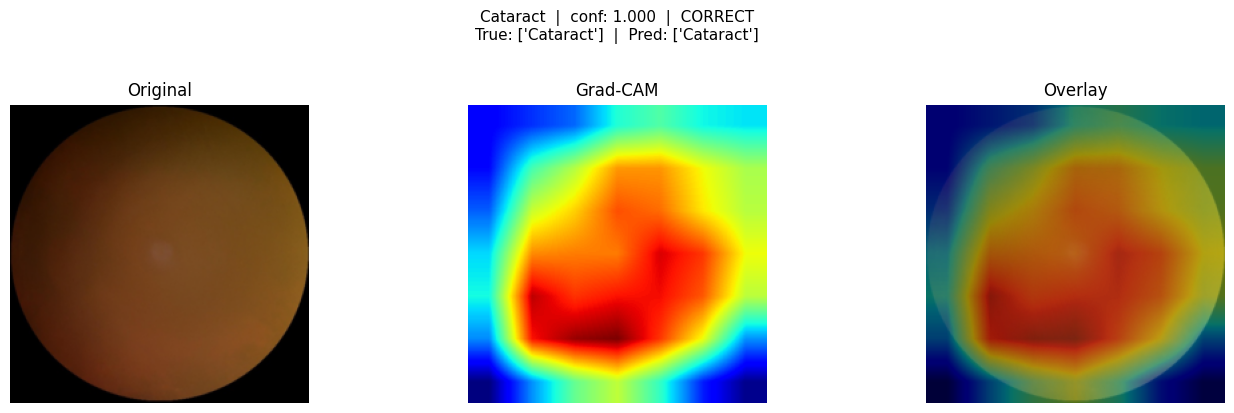


Probabilities:
Normal: 0.0005
Diabetes: 0.0889
Glaucoma: 0.0000
Cataract: 0.9999
AMD: 0.0001
Hypertension: 0.0000
Myopia: 0.0001
Other: 0.0326


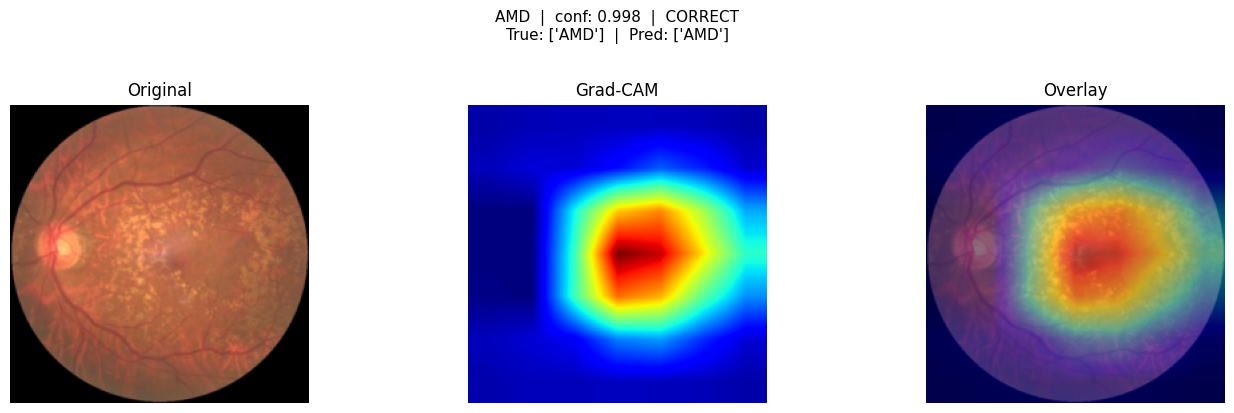


Probabilities:
Normal: 0.0498
Diabetes: 0.0103
Glaucoma: 0.0042
Cataract: 0.0002
AMD: 0.9982
Hypertension: 0.0004
Myopia: 0.0015
Other: 0.0627


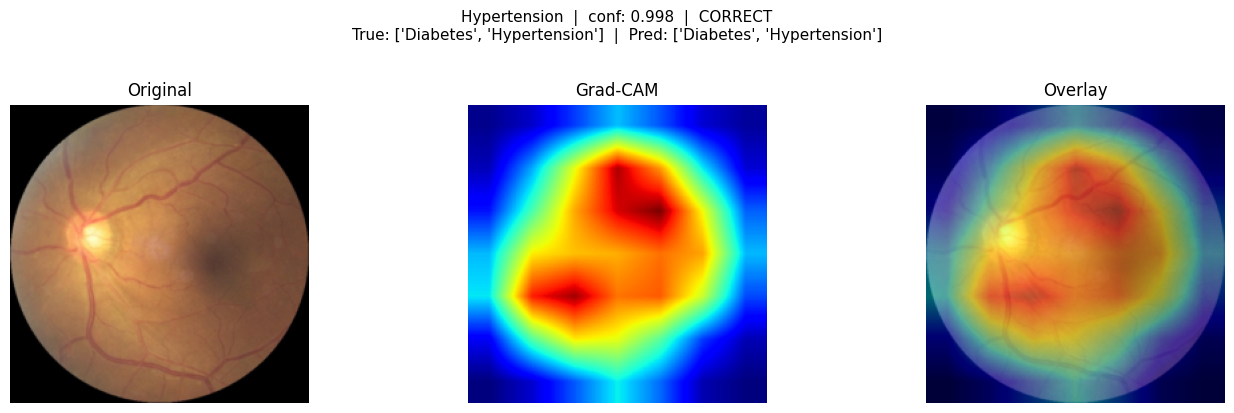


Probabilities:
Normal: 0.1895
Diabetes: 0.6653
Glaucoma: 0.4548
Cataract: 0.0420
AMD: 0.2268
Hypertension: 0.9976
Myopia: 0.0077
Other: 0.2974


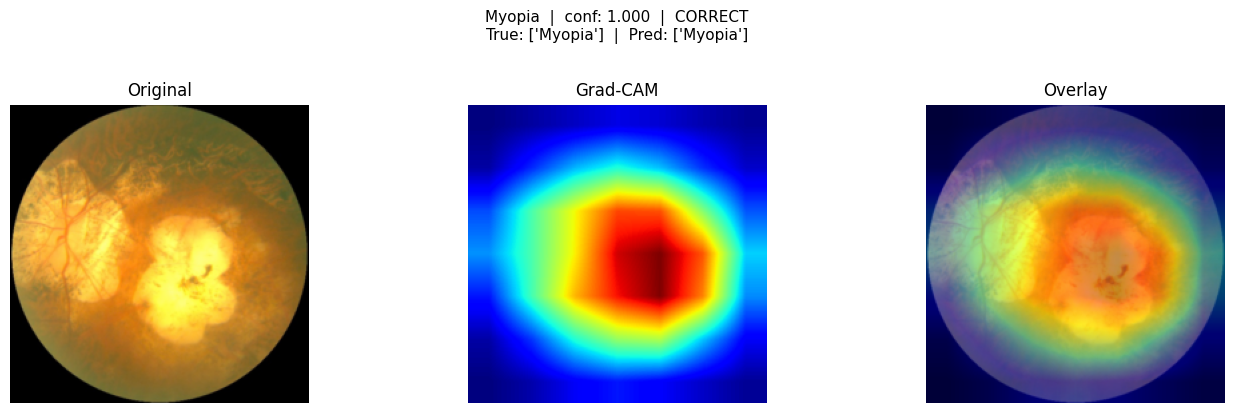


Probabilities:
Normal: 0.0118
Diabetes: 0.0847
Glaucoma: 0.0038
Cataract: 0.0003
AMD: 0.0024
Hypertension: 0.0025
Myopia: 0.9999
Other: 0.3351


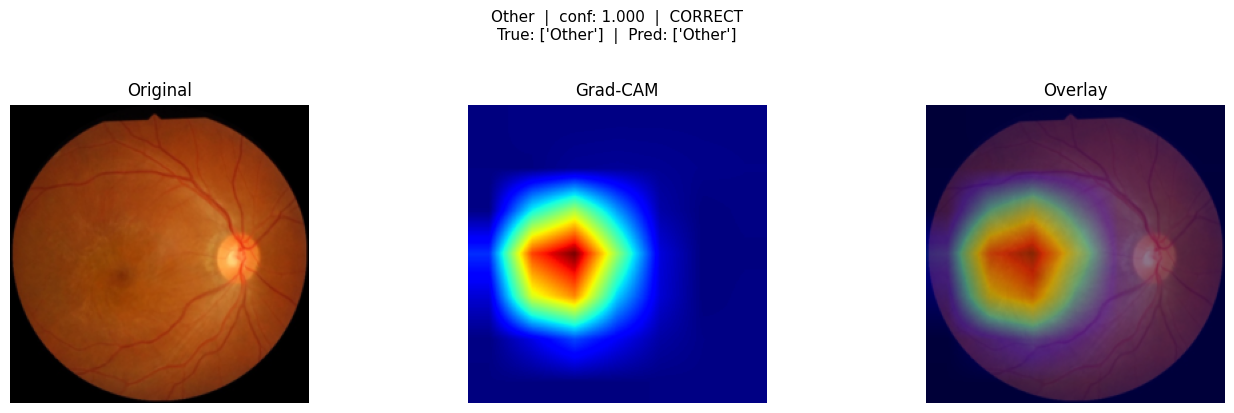


Probabilities:
Normal: 0.0039
Diabetes: 0.0560
Glaucoma: 0.0000
Cataract: 0.0000
AMD: 0.0003
Hypertension: 0.0002
Myopia: 0.0000
Other: 0.9999


In [100]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

def unnormalize_image(tensor):
    img = tensor.detach().cpu().numpy().transpose(1, 2, 0)
    return np.clip(img * IMAGENET_STD + IMAGENET_MEAN, 0, 1)

def get_target_layer(model, model_name):
    name = model_name.lower()
    if name == "efficientnet_b0": return model.features[-1]
    if name in ("resnet18", "resnet50"): return model.layer4[-1]
    if name == "custom_cnn": return model.features[-2]

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, inp, out):
        self.activations = out

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, class_idx):
        self.model.eval()
        self.model.zero_grad()
        logits = self.model(x)
        logits[0, class_idx].backward(retain_graph=True)
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam[0, 0].detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, torch.sigmoid(logits).detach().cpu().numpy()[0]

for m in model.modules():
    if isinstance(m, torch.nn.ReLU):
        m.inplace = False

model.load_state_dict(best_state_f1)
grad_cam = GradCAM(model, get_target_layer(model, MODEL_NAME))

def find_best_example(class_idx):
    best_idx, best_prob = None, 0.0

    for i, sample in enumerate(test_samples):
        if sample["label"][class_idx] != 1:
            continue
        x = val_tfm(Image.open(sample["path"]).convert("RGB")).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            probs_i = torch.sigmoid(model(x))[0].cpu().numpy()
        preds = (probs_i >= best_thresholds).astype(int)
        if np.array_equal(preds, sample["label"]) and probs_i[class_idx] > best_prob:
            best_prob = probs_i[class_idx]
            best_idx = i

    if best_idx is None:
        print(f"{CLASS_NAMES[class_idx]}: no fully correct example, using most confident")
        for i, sample in enumerate(test_samples):
            if sample["label"][class_idx] != 1:
                continue
            x = val_tfm(Image.open(sample["path"]).convert("RGB")).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                p = torch.sigmoid(model(x))[0, class_idx].item()
            if p > best_prob:
                best_prob, best_idx = p, i

    return best_idx, best_prob

def plot_gradcam_for_class(class_idx):
    idx, confidence = find_best_example(class_idx)
    if idx is None:
        print(f"No example found for {CLASS_NAMES[class_idx]}")
        return

    sample = test_samples[idx]
    x = val_tfm(Image.open(sample["path"]).convert("RGB")).unsqueeze(0).to(DEVICE)
    cam, probs = grad_cam.generate(x, class_idx)
    img = unnormalize_image(x[0])

    true_labels = [CLASS_NAMES[i] for i, v in enumerate(sample["label"]) if v == 1]
    pred_labels = [CLASS_NAMES[i] for i, p in enumerate(probs) if p >= best_thresholds[i]]
    correct = sorted(true_labels) == sorted(pred_labels)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(
        f"{CLASS_NAMES[class_idx]}  |  conf: {confidence:.3f}  |  {'CORRECT' if correct else 'PARTIAL'}\n"
        f"True: {true_labels}  |  Pred: {pred_labels}",
        fontsize=11, y=1.02
    )

    axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(cam, cmap="jet"); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
    axes[2].imshow(img); axes[2].imshow(cam, cmap="jet", alpha=0.45); axes[2].set_title("Overlay"); axes[2].axis("off")

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/gradcam_{CLASS_NAMES[class_idx].lower()}.png", dpi=150, bbox_inches="tight")    
    plt.show()

    print(f"\nProbabilities:")
    for i, p in enumerate(probs):
        print(f"{CLASS_NAMES[i]}: {p:.4f}")

for class_idx in range(len(CLASS_NAMES)):
    plot_gradcam_for_class(class_idx)

### Grad-CAM Analysis for Multi-Label Classification

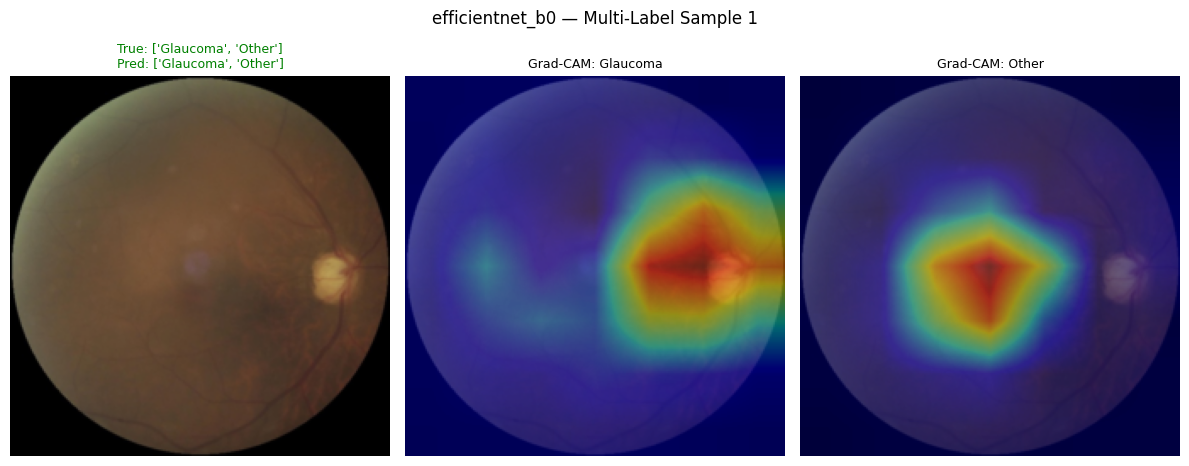

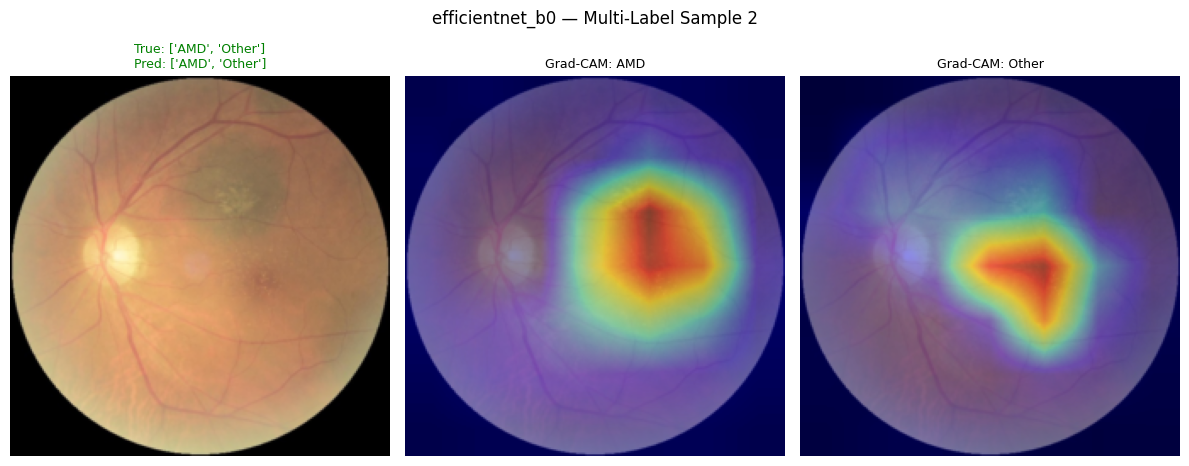

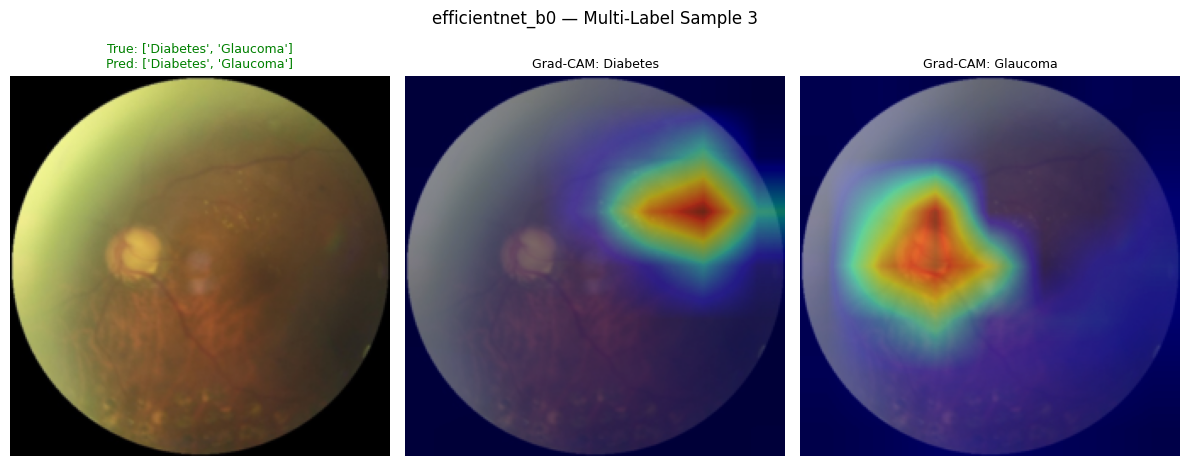

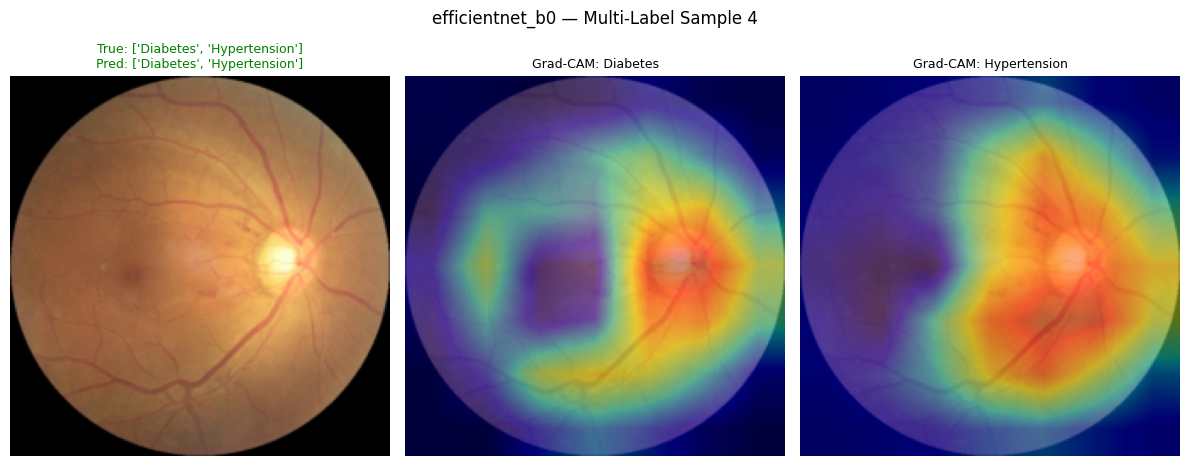

In [101]:
def show_gradcam_multilabel(model, model_name, dataset, n=4):
    for m in model.modules():
        if isinstance(m, torch.nn.ReLU):
            m.inplace = False

    target_layer = get_target_layer(model, model_name)
    found, found_probs = [], []
    model.eval()

    indices = list(range(len(dataset.samples)))
    random.shuffle(indices)

    with torch.no_grad():
        for i in indices:
            s = dataset.samples[i]
            labels = np.array(s["label"])
            if labels.sum() < 2:
                continue
            img_tensor, _ = dataset[i]
            probs = torch.sigmoid(model(img_tensor.unsqueeze(0).to(DEVICE))).cpu().numpy()[0]
            preds = (probs >= best_thresholds).astype(int)
            if np.array_equal(preds, labels):
                found.append(i)
                found_probs.append(probs)
            if len(found) >= n:
                break

    if not found:
        print("No correct multi-label predictions found")
        return

    for num, (idx, probs) in enumerate(zip(found, found_probs)):
        img_tensor, _ = dataset[idx]
        labels = np.array(dataset.samples[idx]["label"])
        true_names = [CLASS_NAMES[i] for i, v in enumerate(labels) if v == 1]
        pred_names = [CLASS_NAMES[i] for i, v in enumerate((probs >= best_thresholds).astype(int)) if v == 1]
        positive_classes = [i for i, v in enumerate(labels) if v == 1]

        fig, axes = plt.subplots(1, 1 + len(positive_classes), figsize=((1 + len(positive_classes)) * 4, 5))
        img = unnormalize_image(img_tensor)

        axes[0].imshow(img)
        axes[0].set_title(f"True: {true_names}\nPred: {pred_names}", fontsize=9, color="green")
        axes[0].axis("off")

        for col, class_idx in enumerate(positive_classes):
            input_tensor = img_tensor.unsqueeze(0).to(DEVICE)
            input_tensor.requires_grad_(True)
            cam, _ = GradCAM(model, target_layer).generate(input_tensor, class_idx)
            axes[col + 1].imshow(img)
            axes[col + 1].imshow(cam, cmap="jet", alpha=0.45)
            axes[col + 1].set_title(f"Grad-CAM: {CLASS_NAMES[class_idx]}", fontsize=9)
            axes[col + 1].axis("off")

        plt.suptitle(f"{model_name} — Multi-Label Sample {num + 1}", fontsize=12)
        plt.tight_layout()
        plt.show()

model.load_state_dict(best_state_f1)
random.seed(66)
show_gradcam_multilabel(model, MODEL_NAME, test_ds, n=4)

### Training history

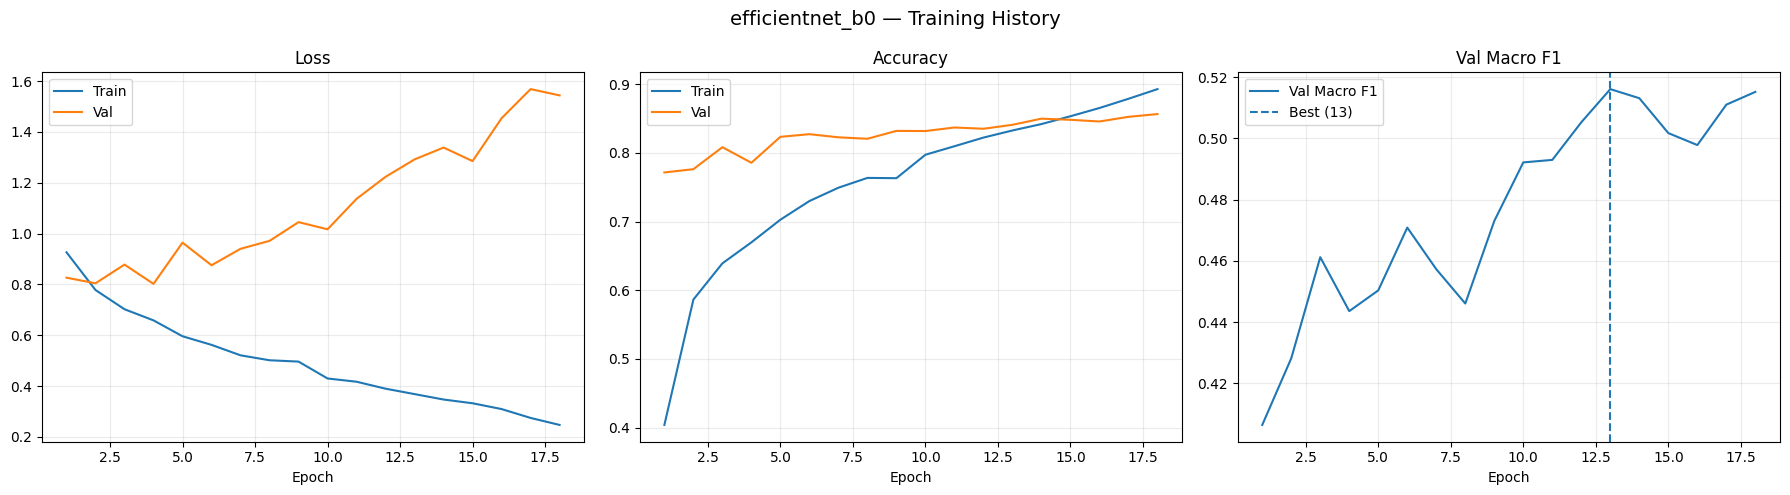

In [102]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.25)

axes[1].plot(history_df["epoch"], history_df["train_acc"], label="Train")
axes[1].plot(history_df["epoch"], history_df["val_acc"], label="Val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.25)

axes[2].plot(history_df["epoch"], history_df["val_macro_f1"], label="Val Macro F1")
axes[2].axvline(best_epoch_f1, linestyle="--", label=f"Best ({best_epoch_f1})")
axes[2].set_title("Val Macro F1"); axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(alpha=0.25)

plt.suptitle(f"{MODEL_NAME} — Training History", fontsize=14)
plt.tight_layout()
plt.show()

### Save to pkl

In [103]:
eval_save = {
    "probs": test_probs,
    "targets": test_targets,
    "preds": (test_probs >= best_thresholds).astype(int),
    "roc_aucs": test_roc_aucs,
    "avg_precs": test_avg_precs,
    "macro_auc": test_macro_auc,
    "macro_ap": test_macro_ap,
    "best_metrics_f1": {
        "macro_f1@0.5": test_metrics["macro_f1"],
        "macro_f1_tuned": test_tuned["macro_f1"],
        "micro_f1@0.5": test_metrics["micro_f1"],
        "exact@0.5": test_metrics["exact_match"],
        "exact_tuned": test_tuned["exact_match"],
        "per_class_f1_tuned": test_tuned["per_class_f1"],
        "loss": test_metrics["loss"],
    },
    "history": history,
    "best_epoch_f1": best_epoch_f1,
    "best_epoch_loss": best_epoch_loss,
    "MODEL_NAME": MODEL_NAME,
}

save_path = f"{CHECKPOINT_DIR}/{MODEL_NAME}_eval_data.pkl"
with open(save_path, "wb") as f:
    pickle.dump(eval_save, f)
print(f"Saved: {save_path}")

Saved: /kaggle/working/checkpoints/efficientnet_b0_eval_data.pkl


### Export Outputs

In [104]:
shutil.make_archive(f"{MODEL_NAME}_outputs", "zip", CHECKPOINT_DIR)
print(f"Download: {MODEL_NAME}_outputs.zip")

Download: efficientnet_b0_outputs.zip
